# 05 — Hull–White: Pricing por Monte Carlo

**Objetivo del notebook.** Validar el estimador Monte Carlo del precio de una opción europea bajo el modelo Hull–White con activo subyacente, y caracterizar su comportamiento numérico.

Se estudian:

1. Cálculo del estimador $\widehat{V}_0^{\,MC}$ con error estándar e intervalo de confianza al 95%.
2. Convergencia del estimador al refinar $N$: tasa empírica frente a la teórica $\mathcal{O}(N^{-1/2})$.
3. Sanity check: degeneración $\eta \to 0$, el estimador HW debe reproducir el precio analítico de Black–Scholes.

Los resultados de este notebook alimentan la Sección 4.5 del capítulo de la tesis.

In [4]:
import sys
sys.path.insert(0, "../src")  # ruta al modulo hullwhite

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from bs_utils import *


from hullwhite import (
    P0T,
    GeneratePathsHWAndAssetEuler,
    PriceEuropeanOptionHWMC,
)


np.set_printoptions(suppress=True, precision=6)

## 1. Parámetros

Fijamos el caso de referencia ATM del Capítulo 4, que se utilizará de forma consistente en los notebooks de griegas en Hull–White.

In [5]:
# Subyacente
S0       = 100.0
sigma_S  = 0.20

# Hull-White (tipo corto)
lambd    = 0.5
eta      = 0.01

# Correlacion browniana asset / tipo corto
rho      = -0.3

# Opcion
K        = 100.0
T        = 1.0

# Simulacion
N        = 20_000   # numero de trayectorias
M        = 250      # numero de pasos temporales
SEED     = 3        # semilla estandar del proyecto

## 2. Estimador puntual del precio

El precio se aproxima por

$$
\widehat{V}_0^{\,MC} \;=\; \frac{1}{N}\sum_{n=1}^N D^{(n)}\,\Phi\!\left(S^{(n)}_{T}\right),
\qquad
D^{(n)} \;=\; \exp\!\left(-\sum_{k=0}^{M-1} r^{(n)}_{t_k}\,\Delta t\right),
$$

con error estándar $\widehat{\mathrm{SE}} = \widehat{\sigma}_Y / \sqrt{N}$, donde $Y^{(n)} = D^{(n)}\Phi(S^{(n)}_T)$.

In [6]:
# Genero las trayectorias conjuntas (r_t, S_t)
paths = GeneratePathsHWAndAssetEuler(
    NoOfPaths=N, NoOfSteps=M, T=T, P0T=P0T,
    lambd=lambd, eta=eta, S0=S0, sigma_S=sigma_S, rho=rho,
    seed=SEED,
)

# Estimador del precio para call y put
price_call, se_call = PriceEuropeanOptionHWMC(paths, K=K, T=T, option_type="call")
price_put,  se_put  = PriceEuropeanOptionHWMC(paths, K=K, T=T, option_type="put")

# Intervalos de confianza al 95%
z = 1.96
ic_call = (price_call - z*se_call, price_call + z*se_call)
ic_put  = (price_put  - z*se_put,  price_put  + z*se_put)

df = pd.DataFrame({
    "Opcion":     ["Call ATM", "Put ATM"],
    "Precio MC":  [price_call, price_put],
    "SE":         [se_call,    se_put],
    "IC95 inf":   [ic_call[0], ic_put[0]],
    "IC95 sup":   [ic_call[1], ic_put[1]],
})
df.round(6)

,Opcion,Precio MC,SE,IC95 inf,IC95 sup
0,Call ATM,10.273246,0.103030,10.071307,10.475185
1,Put ATM,5.582828,0.060906,5.463452,5.702204


## 3. Contraste con Black–Scholes ($r$ constante)

Como referencia, comparamos con el precio analítico de Black–Scholes con tipo determinista $r = r_0 = 0{,}05$. La diferencia entre ambos valores refleja el efecto combinado de la estocasticidad del tipo y de su correlación con el subyacente.

In [7]:
r0 = 0.05  # forward instantanea inicial con curva plana

bs_call = BS_Call_Put_Option_Price("call", S0, K, sigma_S, 0.0, T, r0)
bs_put  = BS_Call_Put_Option_Price("put",  S0, K, sigma_S, 0.0, T, r0)

df_cmp = pd.DataFrame({
    "Opcion":     ["Call ATM", "Put ATM"],
    "BS (r cte)": [bs_call, bs_put],
    "HW MC":      [price_call, price_put],
    "Diferencia": [price_call - bs_call, price_put - bs_put],
    "|Dif| / SE": [abs(price_call - bs_call) / se_call,
                   abs(price_put  - bs_put)  / se_put],
})
df_cmp.round(6)

,Opcion,BS (r cte),HW MC,Diferencia,|Dif| / SE
0,Call ATM,10.450584,10.273246,-0.177337,1.721219
1,Put ATM,5.573526,5.582828,0.009302,0.152725


La columna `|Dif| / SE` mide la diferencia HW–BS en unidades del error estándar de Monte Carlo. Valores moderados (orden 1–3) son compatibles con que el desplazamiento sea atribuible a la dinámica estocástica del tipo, y no a un sesgo del estimador.

## 4. Convergencia del estimador en $N$

Por el teorema central del límite, el error estándar del estimador Monte Carlo decae como $\mathcal{O}(N^{-1/2})$. Verificamos esta tasa empíricamente refinando $N$ y comparando con el ajuste teórico.

Mantenemos $M = 250$ pasos temporales fijos para aislar la componente estadística del error.

In [8]:
Ns = np.array([500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000])

records = []
for n in Ns:
    paths_n = GeneratePathsHWAndAssetEuler(
        NoOfPaths=int(n), NoOfSteps=M, T=T, P0T=P0T,
        lambd=lambd, eta=eta, S0=S0, sigma_S=sigma_S, rho=rho,
        seed=SEED,
    )
    p, se = PriceEuropeanOptionHWMC(paths_n, K=K, T=T, option_type="call")
    records.append({"N": int(n), "Precio MC": p, "SE": se})

df_conv = pd.DataFrame(records)
df_conv.round(6)

,N,Precio MC,SE
0,500,9.921814,0.613778
1,1000,10.856995,0.453406
2,2000,10.133112,0.315443
3,5000,9.909549,0.199642
4,10000,10.384287,0.143814
5,20000,10.273246,0.103030
6,50000,10.453798,0.065845


Pendiente empirica:   -0.4879
Pendiente teorica:   -0.5000


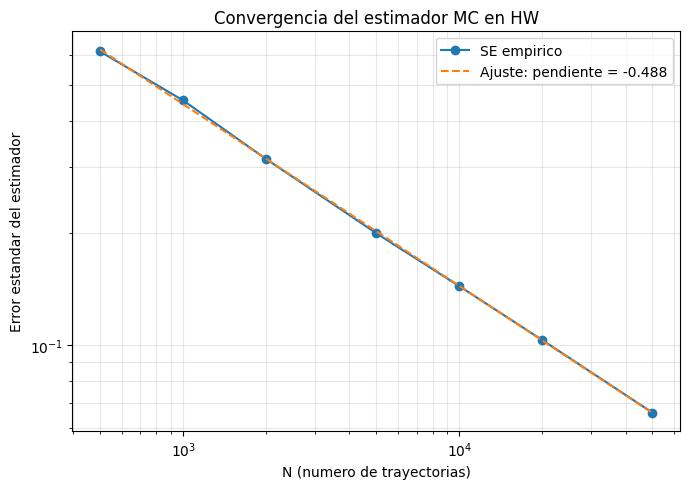

In [9]:
# Ajuste log-log: log(SE) = a + b*log(N), b teorico = -1/2
log_N  = np.log(df_conv["N"].values)
log_SE = np.log(df_conv["SE"].values)
b, a = np.polyfit(log_N, log_SE, 1)

print(f"Pendiente empirica:   {b:.4f}")
print(f"Pendiente teorica:   -0.5000")

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(df_conv["N"], df_conv["SE"], "o-", label="SE empirico")
ax.loglog(df_conv["N"], np.exp(a) * df_conv["N"]**b,
          "--", label=f"Ajuste: pendiente = {b:.3f}")
ax.set_xlabel("N (numero de trayectorias)")
ax.set_ylabel("Error estandar del estimador")
ax.set_title("Convergencia del estimador MC en HW")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

La pendiente empírica debe situarse próxima a $-0{,}5$, confirmando la tasa teórica del teorema central del límite.

## 5. Sanity check: degeneración $\eta \to 0$

En el límite $\eta \to 0$, el tipo corto $r_t$ degenera al caso determinista $r_t \equiv r_0$, y el modelo Hull–White debe reproducir el precio de Black–Scholes. Verificamos esta convergencia tomando valores decrecientes de $\eta$.

Para aislar el efecto de la volatilidad del tipo, fijamos $\rho_{S,r}=0$ en este experimento.

In [7]:
etas = [0.05, 0.02, 0.01, 0.005, 0.001, 0.0001]

records_eta = []
for e in etas:
    paths_e = GeneratePathsHWAndAssetEuler(
        NoOfPaths=50_000, NoOfSteps=M, T=T, P0T=P0T,
        lambd=lambd, eta=e, S0=S0, sigma_S=sigma_S, rho=0.0,
        seed=SEED,
    )
    p, se = PriceEuropeanOptionHWMC(paths_e, K=K, T=T, option_type="call")
    records_eta.append({
        "eta": e,
        "HW MC": p,
        "SE": se,
        "BS (r cte)": bs_call,
        "Diferencia": p - bs_call,
        "|Dif| / SE": abs(p - bs_call) / se,
    })

df_eta = pd.DataFrame(records_eta)
df_eta.round(6)

,eta,HW MC,SE,BS (r cte),Diferencia,|Dif| / SE
0,0.0500,10.560458,0.066434,10.450584,0.109874,1.653882
1,0.0200,10.516418,0.066209,10.450584,0.065834,0.994330
2,0.0100,10.510457,0.066178,10.450584,0.059873,0.904727
3,0.0050,10.509092,0.066171,10.450584,0.058508,0.884196
4,0.0010,10.508820,0.066169,10.450584,0.058237,0.880118
5,0.0001,10.508846,0.066169,10.450584,0.058263,0.880511


La diferencia HW–BS debe estrecharse al disminuir $\eta$, y para valores muy pequeños quedar dentro de pocas desviaciones estándar del estimador. Este experimento valida la consistencia del esquema de simulación conjunta con el caso degenerado conocido.

## 6. Conclusiones

- El estimador Monte Carlo del precio en Hull–White se obtiene como media muestral del payoff descontado por el factor estocástico $D^{(n)}$.
- El error estándar empírico decae como $N^{-1/2}$, en concordancia con el TCL.
- En el límite $\eta \to 0$ se recupera el precio de Black–Scholes, validando la implementación.
- Las cifras obtenidas con los parámetros de referencia se trasladan a la Tabla de la Sección 4.5 de la tesis.
- A partir de este estimador validado, los notebooks siguientes (06–...) abordan el cálculo de griegas en Hull–White.